In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flim.tools_phasor as flim
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.dataio.mcs as mcs
from scipy.ndimage import shift
from skimage.registration import phase_cross_correlation
from brighteyes_flim import calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts, Alignment

def centroid(data):
    x = np.arange(data.size)
    idx = np.sum(x*data)/data.sum()
    return idx

def clean_irf(irf, threshold = 0.3, window = 6):
    
    time = np.arange(irf.size)
    
    t_irf = np.where(irf>threshold, irf, 0)
    
    t0 = centroid(t_irf)
    
    indices = np.argwhere(np.logical_and(time > t0 - window, time < t0 + window))
    
    final_irf = np.zeros_like(irf)
    
    final_irf[indices] = irf[indices]
    
    return final_irf


In [2]:
DATA_CALIBRATE = "/mnt/DATA/Mixed Data/TestGiuse/Coumarine_DFD_calib.h5"


In [3]:
show_h5_structure_html(DATA_CALIBRATE)

'<div class="h5-tree">\n  <style>\n    .h5-tree {\n      color-scheme: light dark;\n      font-family: "Menlo", "Consolas", "DejaVu Sans Mono", monospace;\n      font-size: 13px;\n      line-height: 1.5;\n      color: var(--h5-fg);\n      --h5-fg: #1f2937;\n      --h5-muted: #6b7280;\n      --h5-border: #d1d5db;\n      --h5-group: #0f766e;\n      --h5-dataset: #1d4ed8;\n      --h5-attrs: #7c2d12;\n      --h5-node-ref: #7c3aed;\n      --h5-attr-key: #b45309;\n      --h5-attr-value: #374151;\n      --h5-root: #111827;\n    }\n    @media (prefers-color-scheme: dark) {\n      .h5-tree {\n        --h5-fg: #e5e7eb;\n        --h5-muted: #9ca3af;\n        --h5-border: #4b5563;\n        --h5-group: #5eead4;\n        --h5-dataset: #93c5fd;\n        --h5-attrs: #fdba74;\n        --h5-node-ref: #c4b5fd;\n        --h5-attr-key: #fbbf24;\n        --h5-attr-value: #f3f4f6;\n        --h5-root: #f9fafb;\n      }\n    }\n    .h5-tree ul {\n      list-style: none;\n      margin: 0.2rem 0 0.2rem 1.1rem;\n

In [4]:
hf=h5py.File(DATA_CALIBRATE, "r")
laser_freq_mhz = float(hf["calibration/data"].attrs["laser_freq_in_mhz"]) 
laser_period_ns = float(hf["calibration/data"].attrs["laser_period_in_ns"])
rangex = hf['configurationGUI'].attrs['range_x']
nx = hf['configurationGUI'].attrs['nx']
pixel_size_x_um= rangex / nx
nbin = hf['configurationGUI'].attrs['timebin_per_pixel']
dt = hf['configurationGUI'].attrs['time_resolution']
pxdwelltime = dt * nbin


print("laser_freq_mhz", laser_freq_mhz)
print("laser_period_ns", laser_period_ns)
print("rangex", rangex)
print("nx", nx)
print("pixel_size_x_um", pixel_size_x_um)
print("nbin", nbin)
print("pxdwelltime",pxdwelltime)

print(f"Using calibrated laser timing: {laser_freq_mhz :.4f} MHz ({laser_period_ns:.4f} ns)")

laser_freq_mhz 40.0
laser_period_ns 25.0
rangex 50.0
nx 512
pixel_size_x_um 0.09765625
nbin 91
pxdwelltime 182.0
Using calibrated laser timing: 40.0000 MHz (25.0000 ns)


In [5]:


print(hf.keys())
data_input = hf["data"][:]  # Per-pixel decay histograms, aligned to the excitation timing reference.
channel_skew = hf["calibration/data/channel_skew"][:]
common_delay_in_bins = hf["calibration/data/common_delay_in_bins"][:]
irf_common_delay_realigned = hf["calibration/data/irf_common_delay_realigned"][:]

data_summed_no_alignment = np.sum(data_input,axis=(0,1,2,3,5))
data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0,...]
data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0,...]



<KeysViewHDF5 ['calibration', 'configurationFPGA', 'configurationGUI', 'configurationGUI_beforeStart', 'configurationSpadFCSmanager', 'data', 'data_channels_extra', 'thumbnail']>


In [6]:
irf_common_delay_realigned_clean=np.empty_like(irf_common_delay_realigned)
for i in range(irf_common_delay_realigned.shape[-1]): 
        d=irf_common_delay_realigned[:,i]    
        d=d/d.max()
        k = clean_irf(d, threshold = 0.3, window = 2/(laser_period_ns/nbin))
        irf_common_delay_realigned_clean[:,i]=k
irf_common_delay_realigned = irf_common_delay_realigned_clean
irf_summed = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
irf_summed_no_alignment = irf_common_delay_realigned.sum(axis=-1)
irf_summed_rev = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)



print(data_summed.shape)
print(irf_summed.shape)
print("Channel skew correction applied.")


(512, 512, 91)
(91,)
Channel skew correction applied.


In [7]:
#t_array = np.linspace(0, laser_period_ns, nbin) 
t_array = np.arange(nbin, dtype=float) * laser_period_ns / nbin
t_array


array([ 0.        ,  0.27472527,  0.54945055,  0.82417582,  1.0989011 ,
        1.37362637,  1.64835165,  1.92307692,  2.1978022 ,  2.47252747,
        2.74725275,  3.02197802,  3.2967033 ,  3.57142857,  3.84615385,
        4.12087912,  4.3956044 ,  4.67032967,  4.94505495,  5.21978022,
        5.49450549,  5.76923077,  6.04395604,  6.31868132,  6.59340659,
        6.86813187,  7.14285714,  7.41758242,  7.69230769,  7.96703297,
        8.24175824,  8.51648352,  8.79120879,  9.06593407,  9.34065934,
        9.61538462,  9.89010989, 10.16483516, 10.43956044, 10.71428571,
       10.98901099, 11.26373626, 11.53846154, 11.81318681, 12.08791209,
       12.36263736, 12.63736264, 12.91208791, 13.18681319, 13.46153846,
       13.73626374, 14.01098901, 14.28571429, 14.56043956, 14.83516484,
       15.10989011, 15.38461538, 15.65934066, 15.93406593, 16.20879121,
       16.48351648, 16.75824176, 17.03296703, 17.30769231, 17.58241758,
       17.85714286, 18.13186813, 18.40659341, 18.68131868, 18.95

In [8]:

'''
def perform_fit_data(
    t_array,
    data,
    irf,
    period,
    initial_tau=None,
    initial_dT=None,
    initial_C=None,
    irf_min=1e-5,
    mode="irf_shift",
    fit_type="likelihood",
    force_C_normalized=False,
):
'''  

'\ndef perform_fit_data(\n    t_array,\n    data,\n    irf,\n    period,\n    initial_tau=None,\n    initial_dT=None,\n    initial_C=None,\n    irf_min=1e-5,\n    mode="irf_shift",\n    fit_type="likelihood",\n    force_C_normalized=False,\n):\n'

In [9]:
data_px=data_summed[data_summed.shape[1]//2,data_summed.shape[0]//2,:]
data_px.shape


(91,)

In [10]:
data_px.shape, irf_summed.shape

((91,), (91,))

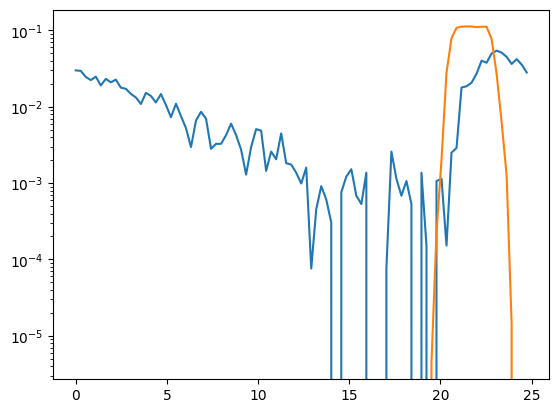

In [11]:
plt.plot(t_array,data_px/data_px.sum())
plt.plot(t_array,irf_summed/irf_summed.sum())
plt.yscale("log")

In [12]:
fit_results = {}
fit_covariances = {}

for fit_type_name in ("curve_fit_circular", "likelihood"):
    fit_results[fit_type_name], fit_covariances[fit_type_name] = Alignment.perform_fit_data(
        t=t_array,
        data=data_px,
        irf=irf_summed,
        period=laser_period_ns,
        initial_tau=4,
        initial_dT=1,
        initial_C=1,
        mode="irf_shift",
        fit_type=fit_type_name,
        force_C_normalized=True,
    )

phasor_corrected_px = flim.calculate_phasor(data_px, threshold=1) / flim.calculate_phasor(irf_summed, threshold=1)
phasor_tau_phi_ns = flim.calculate_tau_phi(phasor_corrected_px, dfd_freq=laser_freq_mhz * 1e6) * 1e9
phasor_tau_m_ns = flim.calculate_tau_m(phasor_corrected_px, dfd_freq=laser_freq_mhz * 1e6) * 1e9

# Keep res as the Poisson likelihood fit, which is less biased for low-count pixels.
res = (fit_results["likelihood"], fit_covariances["likelihood"])

{
    "curve_fit_circular_tau_ns": fit_results["curve_fit_circular"]["tau"],
    "likelihood_tau_ns": fit_results["likelihood"]["tau"],
    "phasor_tau_phi_ns": phasor_tau_phi_ns,
    "phasor_tau_m_ns": phasor_tau_m_ns,
    "likelihood_minus_curve_fit_circular_ns": (
        fit_results["likelihood"]["tau"] - fit_results["curve_fit_circular"]["tau"]
    ),
}


{'curve_fit_circular_tau_ns': np.float64(3.8430012916262957),
 'likelihood_tau_ns': np.float64(4.1839440890372375),
 'phasor_tau_phi_ns': np.float64(4.476366210510037),
 'phasor_tau_m_ns': np.float64(4.12960762283268),
 'likelihood_minus_curve_fit_circular_ns': np.float64(0.3409427974109418)}

In [13]:
import numpy as np
from joblib import Parallel, delayed
from tqdm.auto import tqdm


# -----------------------------
# User parameters
# -----------------------------

initial_tau = 4.0
initial_dT = 1.0
initial_C = 1.0

mode = "irf_shift"
fit_type = "likelihood"
force_C_normalized = True

# Number of parallel workers.
# Use -1 for all cores, or set e.g. 8.
n_jobs = -1


# -----------------------------
# Basic checks
# -----------------------------

data_summed = np.asarray(data_summed, dtype=float)
irf_summed = np.asarray(irf_summed, dtype=float)
#t = np.asarray(t_array, dtype=float)

if data_summed.ndim != 3:
    raise ValueError(f"data_summed must have shape (ny, nx, nbins), got {data_summed.shape}")

ny, nx, nbins = data_summed.shape

if irf_summed.shape != (nbins,):
    raise ValueError(f"irf_summed must have shape ({nbins},), got {irf_summed.shape}")

if t_array.shape != (nbins,):
    raise ValueError(f"t must have shape ({nbins},), got {t_array.shape}")

if not np.all(np.isfinite(irf_summed)) or irf_summed.sum() <= 0:
    raise ValueError("irf_summed contains invalid values or has non-positive sum")

if not np.all(np.isfinite(t_array)):
    raise ValueError("t_array contains invalid values")


# -----------------------------
# Output maps
# -----------------------------

C_map = np.full((ny, nx), np.nan, dtype=float)
dT_map = np.full((ny, nx), np.nan, dtype=float)
tau_map = np.full((ny, nx), np.nan, dtype=float)

C_err_map = np.full((ny, nx), np.nan, dtype=float)
dT_err_map = np.full((ny, nx), np.nan, dtype=float)
tau_err_map = np.full((ny, nx), np.nan, dtype=float)


# -----------------------------
# Pixel mask
# -----------------------------

data_flat = data_summed.reshape(-1, nbins)

valid_mask = (
    np.all(np.isfinite(data_flat), axis=1)
    & (np.sum(data_flat, axis=1) > 0)
)

valid_indices = np.flatnonzero(valid_mask)

print(f"Valid pixels: {len(valid_indices)} / {ny * nx}")


# -----------------------------
# Single-pixel fit function
# -----------------------------

def fit_one_pixel(flat_idx):
    y = flat_idx // nx
    x = flat_idx % nx

    hist = data_summed[y, x, :]

    try:
        res = Alignment.perform_fit_data(
            t=t_array,
            data=hist,
            irf=irf_summed,
            period=laser_period_ns,
            initial_tau=initial_tau,
            initial_dT=initial_dT,
            initial_C=initial_C,
            mode=mode,
            fit_type=fit_type,
            force_C_normalized=force_C_normalized,
        )

        fit_res, cov = res

        C = float(fit_res["C"])
        dT = float(fit_res["dT"])
        tau = float(fit_res["tau"])

        diag = np.diag(cov)

        # Errors are sqrt of covariance diagonal.
        # With force_C_normalized=True, C is fixed, so C_err is usually NaN.
        C_err = np.sqrt(diag[0]) if diag.size > 0 and np.isfinite(diag[0]) and diag[0] >= 0 else np.nan
        dT_err = np.sqrt(diag[1]) if diag.size > 1 and np.isfinite(diag[1]) and diag[1] >= 0 else np.nan
        tau_err = np.sqrt(diag[2]) if diag.size > 2 and np.isfinite(diag[2]) and diag[2] >= 0 else np.nan

        return flat_idx, C, dT, tau, C_err, dT_err, tau_err

    except Exception:
        return flat_idx, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan


# -----------------------------
# Parallel execution
# -----------------------------

results = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=0,
)(
    delayed(fit_one_pixel)(idx)
    for idx in tqdm(valid_indices, desc="Fitting pixels")
)


# -----------------------------
# Fill maps
# -----------------------------

for flat_idx, C, dT, tau, C_err, dT_err, tau_err in results:
    y = flat_idx // nx
    x = flat_idx % nx

    C_map[y, x] = C
    dT_map[y, x] = dT
    tau_map[y, x] = tau

    C_err_map[y, x] = C_err
    dT_err_map[y, x] = dT_err
    tau_err_map[y, x] = tau_err


# -----------------------------
# Compact outputs
# -----------------------------

fit_maps = {
    "C": C_map,
    "dT": dT_map,
    "tau": tau_map,
    "C_err": C_err_map,
    "dT_err": dT_err_map,
    "tau_err": tau_err_map,
}

fit_stack = np.stack(
    [
        C_map,
        dT_map,
        tau_map,
        C_err_map,
        dT_err_map,
        tau_err_map,
    ],
    axis=0,
)

fit_stack_names = [
    "C",
    "dT",
    "tau",
    "C_err",
    "dT_err",
    "tau_err",
]

print("Done.")
print("fit_stack shape:", fit_stack.shape)
print("fit_stack axis 0:", fit_stack_names)

Valid pixels: 262144 / 262144


Fitting pixels:   0%|          | 0/262144 [00:00<?, ?it/s]

Done.
fit_stack shape: (6, 512, 512)
fit_stack axis 0: ['C', 'dT', 'tau', 'C_err', 'dT_err', 'tau_err']


In [14]:
np.savez("/tmp/img.npz", fit_maps=fit_maps)

In [15]:
fit_maps=np.load("/tmp/img.npz", allow_pickle=True)["fit_maps"][()]
fit_maps


{'C': array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(512, 512)),
 'dT': array([[ 2.96189691e-08,  1.91196643e-01, -6.75153530e-02, ...,
         -1.13979477e-02,  1.72005862e-01, -2.25779577e-01],
        [-3.88310300e-02,  2.80942336e-02, -1.41878457e-01, ...,
          2.29308604e-01, -8.34518983e-02, -1.36548732e-01],
        [-2.76424546e-01,  1.31998232e-01,  8.96370996e-02, ...,
         -2.36354621e-01, -2.73562959e-01,  1.76788740e-01],
        ...,
        [-1.74413688e-01, -2.30314904e-01, -1.62980211e-01, ...,
         -1.27622703e-01, -9.82931175e-02, -2.91266454e-01],
        [ 5.36807243e-02, -1.41856639e-01,  2.79200217e-01, ...,
         -2.31329101e-02,  1.38037425e-01,  2.25677703e-06],
        [-1.50315841e-01, -3.57580839e-02, -7.09672906e-07, ...,
          9.35

In [16]:
tau=fit_maps["tau"]

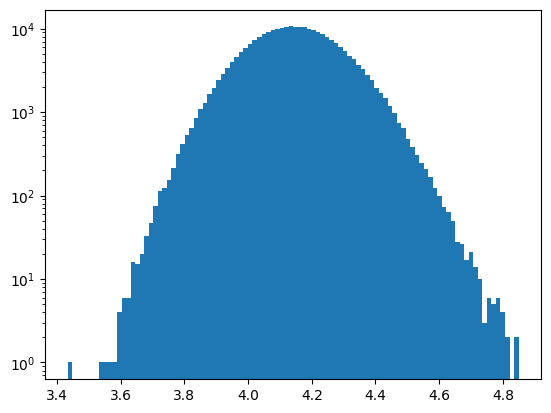

In [17]:
plt.hist(tau.flatten(),bins=100)
plt.yscale("log")


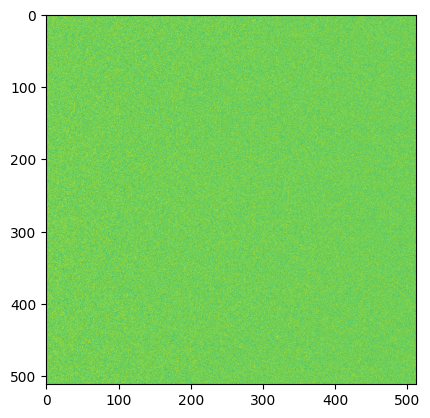

In [18]:
plt.imshow(tau,vmin=1,vmax=5)

In [19]:
import brighteyes_ism.analysis.Graph_lib as gra


In [20]:
intensity=data_summed.sum(axis=-1)
intensity.shape

(512, 512)

(<Figure size 640x480 with 2 Axes>, <Axes: >)

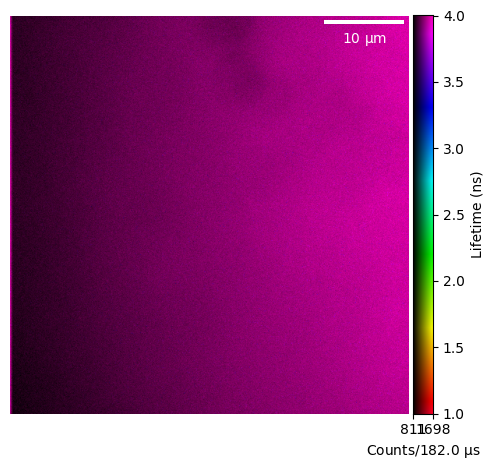

In [21]:
gra.show_flim(intensity, tau,pxsize=pixel_size_x_um, pxdwelltime=pxdwelltime,lifetime_bounds=[1,4])


In [22]:
intensity_map = intensity 
lifetime_map = tau



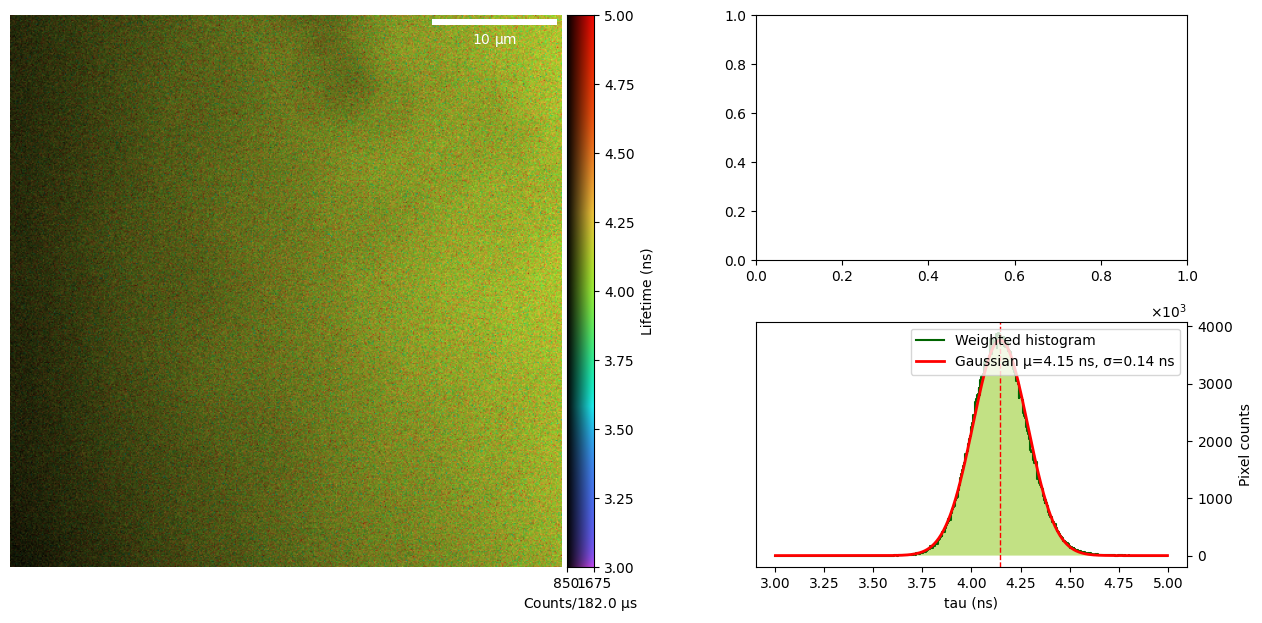

In [23]:
from matplotlib.ticker import ScalarFormatter

crop = 30
cmap = 'turbo'

upper_bound = 5.
lower_bound = 3.

bin_plot = 500

fig = plt.figure(figsize = (18, 12))
gs = fig.add_gridspec(4, 4)

ax1 = fig.add_subplot(gs[0:2, 0:2])


gra.show_flim(intensity_map[crop:-crop, crop:-crop], lifetime_map[crop:-crop, crop:-crop], pixel_size_x_um, pxdwelltime, lifetime_bounds = [lower_bound,upper_bound], fig = fig, ax = ax1, colormap=cmap)

ax3 = fig.add_subplot(gs[0, 2:3])
ax4 = fig.add_subplot(gs[1, 2:3])

#flim.plot_phasor(thresholded_phasor_map, quadrant='first', bins_2dplot = bin_plot, cmap='viridis', dfd_freq = laser_freq_mhz*1e6,  fig = fig, ax = ax3)
# Alternative histogram call kept here for quick experimentation.
# Weighted histogram + Gaussian overlay (mean and RMS)
weights = intensity_map.flatten()
vals = lifetime_map.flatten()
mask = np.isfinite(vals) & np.isfinite(weights) & (weights > 0)
vals = vals[mask]
weights = weights[mask]
n, bins = np.histogram(vals, bins=500, range=(lower_bound, upper_bound), weights=weights)
bin_centers = 0.5*(bins[:-1] + bins[1:])
ax4.plot(bin_centers, n, drawstyle='steps-mid', color='darkgreen', linewidth=1.5, label='Weighted histogram')
ax4.fill_between(bin_centers, n, step='mid', facecolor='yellowgreen', alpha=0.6)
# weighted mean and RMS
mean_tau = np.average(vals, weights=weights) if weights.sum() > 0 else np.nan
var = np.average((vals - mean_tau) ** 2, weights=weights) if weights.sum() > 0 else np.nan
rms_tau = np.sqrt(var) if np.isfinite(var) else np.nan
# Gaussian (scaled to histogram counts)
gauss = np.exp(-0.5 * ((bin_centers - mean_tau) / rms_tau) ** 2)
if gauss.sum() > 0:
    gauss_scaled = gauss * (n.sum() / gauss.sum())
else:
    gauss_scaled = gauss
ax4.plot(bin_centers, gauss_scaled, color='red', linewidth=2, label=f'Gaussian μ={mean_tau:.2f} ns, σ={rms_tau:.2f} ns')
ax4.axvline(mean_tau, color='red', linestyle='--', linewidth=1)
#ax4.set_yscale("log")
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position("right")
ax4.set_xlabel('tau (ns)')
ax4.set_ylabel('Pixel counts')
ax4.legend(loc='upper right')

sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((3,3))
ax4.yaxis.set_major_formatter(sf)






/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1745608/1979644816.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


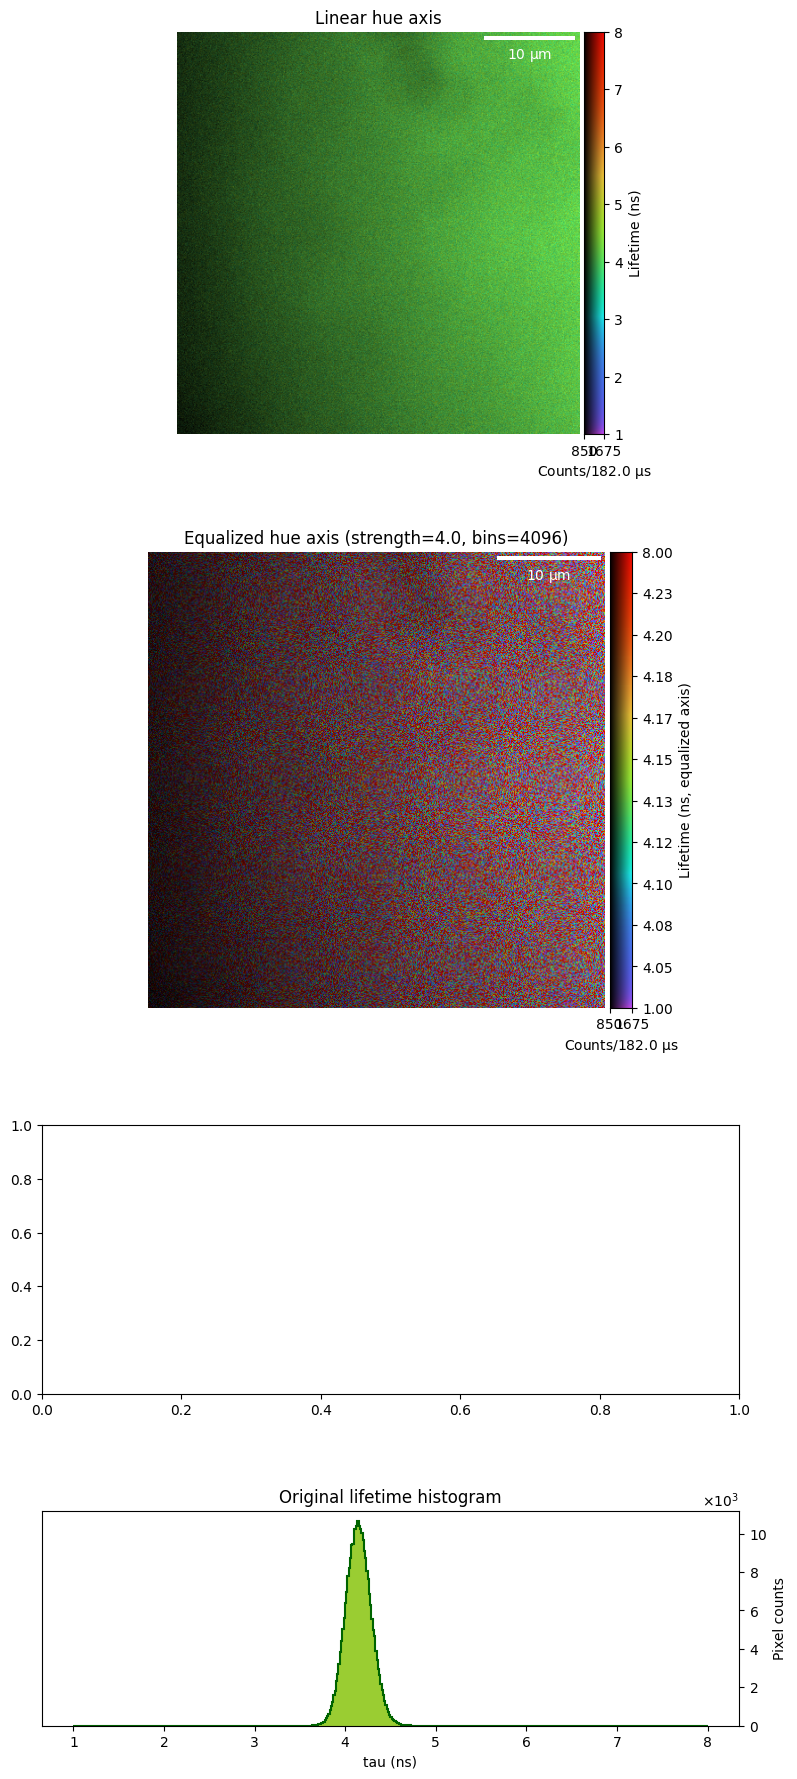

In [24]:
from matplotlib.ticker import ScalarFormatter

crop = 30
cmap = 'turbo'
equalization_strength = 4.0
equalization_bins = 4096
equalization_tick_count = 12

upper_bound = 8
lower_bound = 1.
lifetime_bounds = [lower_bound, upper_bound]

bin_plot = 500

display_intensity = intensity_map[crop:-crop, crop:-crop]
display_lifetime = lifetime_map[crop:-crop, crop:-crop]
equalization_reference = tau_map

fig = plt.figure(figsize=(9, 22))
gs = fig.add_gridspec(4, 1, height_ratios=[1.5, 1.7, 1.0, 0.8], hspace=0.35)


ax1 = fig.add_subplot(gs[0, 0])
gra.show_flim(
    display_intensity,
    display_lifetime,
    pixel_size_x_um,
    pxdwelltime,
    lifetime_bounds=lifetime_bounds,
    fig=fig,
    ax=ax1,
    colormap=cmap,
)
ax1.set_title('Linear hue axis')

ax2 = fig.add_subplot(gs[1, 0])
flim.show_flim_equalized(
    display_intensity,
    display_lifetime,
    pixel_size_x_um,
    pxdwelltime,
    lifetime_bounds=lifetime_bounds,
    fig=fig,
    ax=ax2,
    colormap=cmap,
    equalization_reference=equalization_reference,
    equalization_strength=equalization_strength,
    equalization_bins=equalization_bins,
    colorbar_ticks=equalization_tick_count,
)
ax2.set_title(
    f'Equalized hue axis (strength={equalization_strength:.1f}, bins={equalization_bins})'
)

ax3 = fig.add_subplot(gs[2, 0])
ax4 = fig.add_subplot(gs[3, 0])


ax4.hist(
    tau_map.flatten(),
    bins=500,
    range=(lower_bound, upper_bound),
    histtype='step',
    fill=True,
    fc='yellowgreen',
    edgecolor='darkgreen',
    linewidth=1.5,
)
ax4.yaxis.tick_right()
ax4.yaxis.set_label_position('right')
ax4.set_xlabel('tau (ns)')
ax4.set_ylabel('Pixel counts')
ax4.set_title('Original lifetime histogram')
sf = ScalarFormatter(useMathText=True)
sf.set_powerlimits((3, 3))
ax4.yaxis.set_major_formatter(sf)
fig.tight_layout()
